In [27]:
import warnings
warnings.filterwarnings('ignore')

In [28]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from matplotlib.colors import XKCD_COLORS
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.linalg import orthogonal_procrustes
import plotly.express as px
import cupy as cp
from cuml.decomposition import PCA as cuPCA

Now that we have a dataset, the first thing we need to do is load it and visualize it.

In [4]:
gen_data_dir = "./datasets/"
data_prefix = "dataset_task-memoryscenes_roi-fef_r"
control_prefix = "dataset_task-memoryscenes_roi-rnd_wb"
results_dir = "./analyses/"

Unfortunately, it isn't possible to visualize all the voxels. However, what we can do is reduce the dimensions as much as possible. Let's aim to capture at least 97% of the data. One option is of course, t-SNE, but let's try PCA first to get rid of the noise.

In [58]:
def gpu_pca_by_threshold(data, pc_number, threshold):
    data_gpu = cp.array(data, dtype=cp.float32)
    gpu_pca = cuPCA(n_components=pc_number, svd_solver='full')
    reduced_x_gpu = gpu_pca.fit_transform(data_gpu)
    pca_x_cpu = reduced_x_gpu.get()

    exp_var = gpu_pca.explained_variance_ratio_.get()
    cum_exp_var = np.cumsum(exp_var)
    threshold_match = np.where(cum_exp_var>=threshold)[0][0]
    reduced_x = pca_x_cpu[:,0:threshold_match+1]
    return reduced_x, gpu_pca, pca_x_cpu

In [80]:
def pca_by_threshold(data, threshold=0.97):
    pca = PCA()
    pca_x = pca.fit_transform(data)
    exp_var = pca.explained_variance_ratio_
    cum_exp_var = np.cumsum(exp_var)
    threshold_match = np.where(cum_exp_var>=threshold)[0][0]
    reduced_x = pca_x[:,0:threshold_match+1]
    return reduced_x, pca

In [7]:
def pca_scree_plot(model):
    
    exp_var = model.explained_variance_ratio_
    cum_exp_var = np.cumsum(exp_var)

    fig, ax = plt.subplots(2,1, figsize=(16,8))
    sns.lineplot(x=np.arange(exp_var.shape[0]), y=exp_var, color=XKCD_COLORS["xkcd:rose pink"], ax=ax[0])
    sns.lineplot(x=np.arange(exp_var.shape[0]), y=cum_exp_var, color=XKCD_COLORS["xkcd:seafoam"], ax=ax[1])
    ax[1].set_xlabel("Principal Component Number")
    ax[0].set_ylabel("Variance Explained")
    ax[1].set_ylabel("Cumulative Variance Explained")

    return fig, ax

In [32]:
def gpu_pca_scree_plot(model):
    
    exp_var = model.explained_variance_ratio_.get()
    cum_exp_var = np.cumsum(exp_var)

    fig, ax = plt.subplots(2,1, figsize=(16,8))
    sns.lineplot(x=np.arange(exp_var.shape[0]), y=exp_var, color=XKCD_COLORS["xkcd:rose pink"], ax=ax[0])
    sns.lineplot(x=np.arange(exp_var.shape[0]), y=cum_exp_var, color=XKCD_COLORS["xkcd:seafoam"], ax=ax[1])
    ax[1].set_xlabel("Principal Component Number")
    ax[0].set_ylabel("Variance Explained")
    ax[1].set_ylabel("Cumulative Variance Explained")

    return fig, ax

In [8]:
def create_3d_dataset(data, orig_df):
    tsne = TSNE(n_components=3, 
            perplexity=30, 
            random_state=42
           )
    tsne_3d = tsne.fit_transform(data)
    tsne_df = pd.DataFrame(tsne_3d, columns=['x', 'y', 'z'])
    tsne_df['Time'] = orig_df['scan_time']
    tsne_df['Runs'] = orig_df['run']
    tsne_df['Subjects'] = orig_df['subj']
    tsne_df['Session'] = orig_df['sess']
    return tsne_df

In [9]:
def visualize_3d_data(df_3d, roi_label, color_by=None):
    fig = px.scatter_3d(df_3d, x='x', y='y', z='z', color=color_by, opacity=0.7, 
                        size_max=3, title=f"3D t-SNE of {roi_label} by {color_by}")
    fig.show(renderer="iframe")

------------

## Loading and Visualizing Data ##

#### Loading the datasets ####

In [10]:
rnd_df = pd.read_parquet(gen_data_dir+control_prefix+'/'+control_prefix+'_-15_-1_-3_date-2026-03-08_desc-vox_w_stim_hrf.parquet')
rnd_df.head()

,scan_time,v0,v1,v2,v3,v4,v5,v6,v7,v8,...,v4164,v4165,v4166,v4167,v4168,indoor,outdoor,subj,sess,run
0,0.0,-0.000008,0.000021,0.000031,0.000000,0.000000,0.000025,0.000000,0.000023,-0.000016,...,0.000031,0.00000,0.000009,0.000000,0.000000,0.0,0.0,1,1,1
1,2.2,-0.000016,0.000021,0.000031,0.000000,0.000000,0.000025,0.000000,0.000016,-0.000016,...,0.000031,0.00001,0.000018,0.000000,0.000000,0.0,0.0,1,1,1
2,4.4,-0.000008,0.000021,0.000038,0.000008,-0.000011,0.000025,0.000000,0.000023,-0.000008,...,0.000023,-0.00001,0.000000,-0.000016,0.000000,0.0,0.0,1,1,1
3,6.6,-0.000016,0.000021,0.000023,-0.000017,0.000011,0.000032,0.000000,0.000008,-0.000041,...,0.000054,0.00004,0.000044,0.000032,0.000000,0.0,0.0,1,1,1
4,8.8,-0.000008,0.000027,0.000054,0.000041,-0.000034,0.000006,0.000007,0.000047,0.000033,...,-0.000015,-0.00008,-0.000062,-0.000065,0.000007,0.0,0.0,1,1,1


In [11]:
roi_df = pd.read_parquet(gen_data_dir+data_prefix+"/"+data_prefix+"_24_-2_-20_date-2026-03-08_desc-vox_w_stim_hrf.parquet")
roi_df.head()

,scan_time,v0,v1,v2,v3,v4,v5,v6,v7,v8,...,v33396,v33397,v33398,v33399,v33400,indoor,outdoor,subj,sess,run
0,0.0,-0.000006,0.000000,-0.000007,-0.000008,0.000009,0.000007,-0.000008,0.000013,-0.000014,...,0.000006,-0.000007,-0.000007,0.000013,0.000013,0.0,0.0,1,1,1
1,2.2,-0.000006,0.000000,-0.000007,-0.000008,0.000000,0.000000,-0.000008,0.000013,-0.000014,...,0.000006,-0.000007,-0.000007,0.000020,0.000013,0.0,0.0,1,1,1
2,4.4,-0.000006,0.000014,0.000007,0.000000,0.000028,0.000022,0.000000,0.000019,-0.000014,...,-0.000006,-0.000021,-0.000013,0.000007,0.000020,0.0,0.0,1,1,1
3,6.6,0.000006,-0.000035,-0.000028,-0.000023,-0.000046,-0.000037,-0.000033,0.000000,-0.000007,...,0.000031,0.000014,0.000020,0.000039,0.000007,0.0,0.0,1,1,1
4,8.8,-0.000025,0.000077,0.000042,0.000030,0.000111,0.000088,0.000041,0.000032,-0.000014,...,-0.000055,-0.000062,-0.000054,-0.000033,0.000033,0.0,0.0,1,1,1


In [12]:
roi_cols = [name for name in roi_df.columns if name[0]=='v']
rnd_cols = [name for name in rnd_df.columns if name[0]=='v']

In [97]:
max_vals = roi_df[roi_cols].abs().max()
valid_voxels = max_vals[max_vals < 20].index.tolist()
x = roi_df.loc[:, valid_voxels].copy()
y = roi_df[['indoor', 'outdoor']].copy()

In [100]:
max_vals = rnd_df[rnd_cols].abs().max()
valid_voxels = max_vals[max_vals < 20].index.tolist()
rx = rnd_df.loc[:, valid_voxels].copy()
ry = rnd_df[['indoor', 'outdoor']].copy()

In [13]:
rng = np.random.default_rng()

Make sure that the dataframes do not have nans. If there are nans, then fill with average between upper and lower rows.

In [15]:
roi_df.dropna().shape==roi_df.shape

True

In [18]:
rnd_df.dropna().shape==rnd_df.shape

True

We do not have any nans, so there is no interpolation step. Instead, because these datasets are gigantic, let's first reduce them to manageable sizes.

#### Reducing dimensionality via PCA ####

First, let's reduce the dimensions by dropping 3% of the principal components that least explain the variance in the data.

In [89]:
roi_pca_x_cpu, roi_pca_model_cpu = pca_by_threshold(x, threshold=0.97)

In [102]:
roi_pca_x_97, roi_pca_model, roi_pca_x = gpu_pca_by_threshold(x, pc_number=1000, threshold=0.97)

In [103]:
rnd_pca_x_97, rnd_pca_model, rnd_pca_x = gpu_pca_by_threshold(rx, pc_number=1000, threshold=0.97)

And now we see how much of the variance in each dataset the principal components explain.

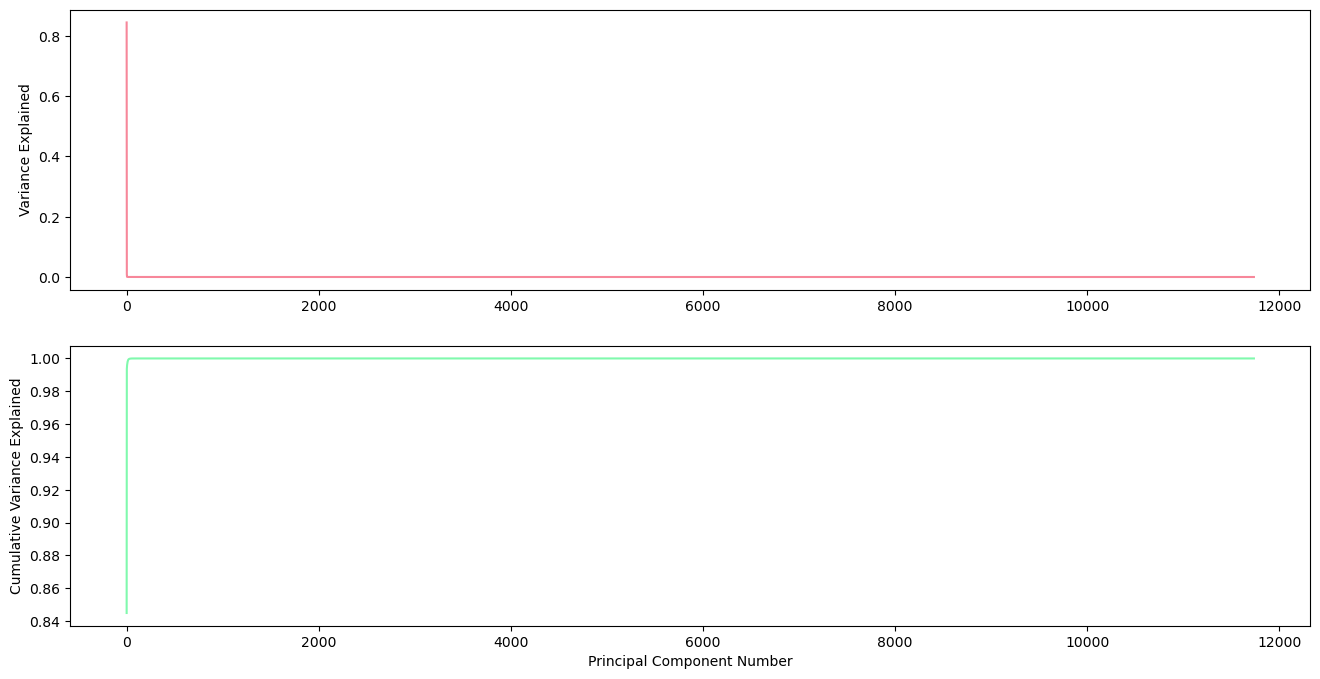

In [104]:
fig, ax = pca_scree_plot(roi_pca_model_cpu)

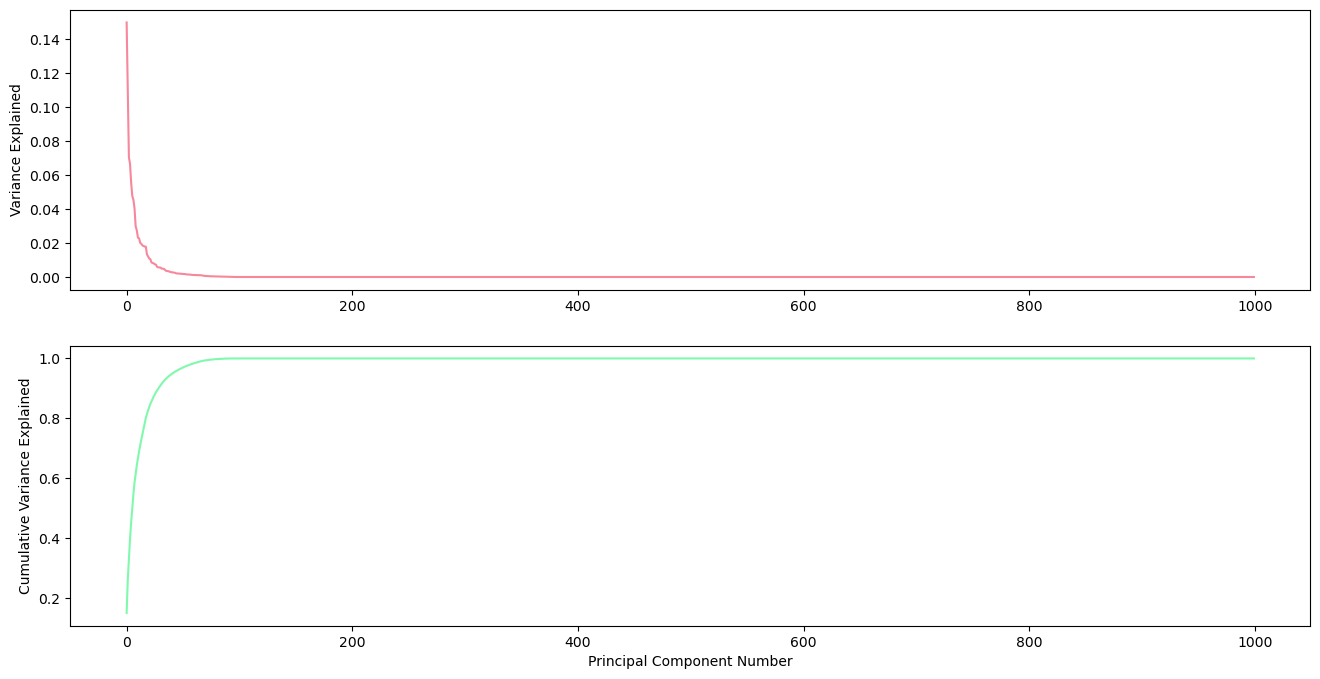

In [105]:
fig, ax = gpu_pca_scree_plot(roi_pca_model)

In [106]:
print(f"There are {roi_pca_x_97.shape[1]} principal components for the ROI dataset, and there are {rnd_pca_x_97.shape[1]} principal components for the Random Location dataset.")

There are 52 principal components for the ROI dataset, and there are 14 principal components for the Random Location dataset.


We can see that we can capture most of the data with relatively few components. Henceforth, all analyses will be on the principal component dataset. 
We will now take those principle components and further reduce them into three dimensions so that we can visualize the data.

In [ ]:
# In the event that you need more than 3 principal components, comment out the following:
roi_3d_df = create_3d_dataset(roi_pca_x_97, roi_df)
rnd_3d_df = create_3d_dataset(rnd_pca_x_97, rnd_df)

In [ ]:
visualize_3d_data(roi_3d_df, 'rFEF', color_by='Subjects')

In [ ]:
visualize_3d_data(rnd_3d_df, 'Random', color_by='Subjects')

Let's also compare the structure of activity at the ROI vs Random locations in a couple subjects.

In [ ]:
subj10 = pd.concat([roi_3d_df[roi_3d_df['Subjects']==10], rnd_3d_df[rnd_3d_df['Subjects']==10]], ignore_index=True)
bloc = np.zeros(subj10.shape[0])
bloc[:(subj10.shape[0]//2)+1] = 1
subj10['Brain_Loc'] = bloc
visualize_3d_data(subj10, 'Subject 10', color_by='Brain_Loc')

In [ ]:
subj05 = pd.concat([roi_3d_df[roi_3d_df['Subjects']==5], rnd_3d_df[rnd_3d_df['Subjects']==5]], ignore_index=True)
bloc = np.zeros(subj05.shape[0])
bloc[:(subj05.shape[0]//2)+1] = 1
subj05['Brain_Loc'] = bloc
visualize_3d_data(subj05, 'Subject 05', color_by='Brain_Loc')

The ROI and Random locations really aren't very similar within subjects. However, visually, the Random location looks similar between subjects. Let's take a look at that too.

In [ ]:
rnd_5_10 = pd.concat([rnd_3d_df[rnd_3d_df['Subjects']==5], rnd_3d_df[rnd_3d_df['Subjects']==10]], ignore_index=True)
visualize_3d_data(rnd_5_10, 'Random Location Activity', color_by='Subjects')

In [ ]:
roi_5_10 = pd.concat([roi_3d_df[roi_3d_df['Subjects']==5], roi_3d_df[roi_3d_df['Subjects']==10]], ignore_index=True)
visualize_3d_data(roi_5_10, 'ROI Activity', color_by='Subjects')

Evidently, there is little similarity between or within subjects. It looks like there _might_ be some kind of order here overall, but, right now, it's all a mess of strings. What we do know is that the answer _isn't_ scaling the data because they were scaled during timeseries extraction. 

-------

## Data Alignment ##

The data as visualized above look like they are almost but not quite in the same rotation. To account for this, we can use hyperalignment techniques to put the data into the same plane of reference.

In [ ]:
def hyperaligner(fixed_target, rotate_df, feature_list):
    transforming_matrix = rotate_df.loc[:,feature_list].to_numpy()
    transformation_matrix, _ = orthogonal_procrustes(transforming_matrix, fixed_target)
    transformed_matrix = transforming_matrix @ transformation_matrix
    ccf = np.corrcoef(transformed_matrix.flatten(),fixed_target.flatten())[0,1]
    return transformation_matrix, ccf

In [ ]:
def pass_idx(new_df, old_df):
    new_df['Subject'] = old_df['subj']
    new_df['Session'] = old_df['sess']
    new_df['Run'] = old_df['run']
    new_df['Time'] = old_df['scan_time']
    new_df['Indoor'] = old_df['indoor']
    new_df['Outdoor'] = old_df['outdoor']
    return new_df

In [ ]:
def best_transformation_target_finder(df, feature_list):
    master_tmat_list = []
    master_corr_list = []
    corr_sum_list = []
    
    for sub in df['subj'].unique():
        sub_idx = df[df['subj']==sub].copy()
        tmp_tmat = []
        tmp_corr = []
        
        for s in sub_idx['sess'].unique():
            tmat_list = []
            corr_list = []
            target = sub_idx[sub_idx['sess']==s].loc[:,feature_list].to_numpy()
            maxcoeff = []
            
            for t in sub_idx['sess'].unique():
    
                if t==s:
                    continue
    
                sub_ses_df = sub_idx[sub_idx['sess']==t]
                transformation_matrix, ccf = hyperaligner(target, sub_ses_df, feature_list)
                
                tmat_list.append((t, transformation_matrix))
                corr_list.append((t, ccf))
                maxcoeff.append(ccf)
            tmp_tmat.append((s, tmat_list))
            tmp_corr.append((s, max(maxcoeff)))
        master_tmat_list.append((sub, tmp_tmat))
        master_corr_list.append((sub, tmp_corr))
    return master_tmat_list, master_corr_list

In [ ]:
def best_transformation(correlation_list):
    max_idx = {}
    for sub in correlation_list:
        id_finder = []
        for sess in sub[1]:
            id_finder.append(sess[1])
        idx = np.where(id_finder==np.max(id_finder))
        max_idx[sub[0]] = idx
    return max_idx

In [ ]:
def transformer(df, feature_list, transformation_mat_list, correlation_list):
    corr_idx = best_transformation(correlation_list)
    x_proc = df[feature_list].copy()
    for i, sub in enumerate(df['subj'].unique()):
        sub_idx = df[df['subj']==sub].copy()
        mid = corr_idx[sub][0][0]
        
        for j, s in enumerate(transformation_mat_list[i][1][mid][1]):
    
            transformation_matrix = s[1] # the template transformations
            transforming_matrix = sub_idx[sub_idx['sess']==s[0]].loc[:,feature_list].to_numpy()
            transformed_matrix = transforming_matrix @ transformation_matrix
            x_proc.loc[sub_idx[sub_idx['sess']==s[0]].index,feature_list] = transformed_matrix
    x_proc = pass_idx(x_proc, df)
    return x_proc

In [ ]:
roi_3d_df = roi_3d_df.rename(columns={'Subjects':'subj', 'Session':'sess', 'Run':'run', 'Runs':'run', 'Time':'scan_time'})
roi_3d_df[['indoor', 'outdoor']] = y

In [ ]:
rnd_3d_df = rnd_3d_df.rename(columns={'Subjects':'subj', 'Session':'sess', 'Run':'run', 'Runs':'run', 'Time':'scan_time'})
rnd_3d_df[['indoor', 'outdoor']] = ry

In [ ]:
roi_trans_list, roi_corr_list = best_transformation_target_finder(roi_3d_df, ['x', 'y', 'z'])
roi_x_proc = transformer(roi_3d_df, ['x', 'y', 'z'], roi_trans_list, roi_corr_list)

In [ ]:
# Full dataset instead of the reduced-to-3D dataset
roi_trans_list, roi_corr_list = best_transformation_target_finder(roi_df, roi_cols)
roi_proc_df = transformer(roi_df, roi_cols, roi_trans_list, roi_corr_list)

In [ ]:
roi_pca_df = pd.DataFrame(roi_pca_x, columns=['pc'+str(n) for n in range(roi_pca_x.shape[1])])
info_cols = [name for name in roi_df.columns if name[0]!='v']
roi_pca_df[info_cols] = roi_df[info_cols]

In [ ]:
roi_trans_list, roi_corr_list = best_transformation_target_finder(roi_pca_df, ['pc'+str(n) for n in range(roi_pca_x.shape[1])])
roi_pca_proc = transformer(roi_pca_df, ['pc'+str(n) for n in range(roi_pca_x.shape[1])], roi_trans_list, roi_corr_list)

In [ ]:
roi_pca_proc_3d = create_3d_dataset(roi_pca_proc, roi_df)

In [ ]:
visualize_3d_data(roi_x_proc[roi_x_proc['Subject']==1], 'rFEF', 'Session')

In [ ]:
visualize_3d_data(roi_pca_proc_3d[roi_pca_proc_3d['Subjects']==1], 'rFEF', 'Session')

In [ ]:
roi_pca_proc_3d[y.columns] = y

In [ ]:
visualize_3d_data(roi_pca_proc_3d[roi_pca_proc_3d['Subjects']==1], 'rFEF', 'indoor')

In [ ]:
visualize_3d_data(roi_pca_proc_3d[(roi_pca_proc_3d['Subjects']==2) & (roi_pca_proc_3d['Session']==1)], 'rFEF', 'indoor')

In [ ]:
visualize_3d_data(roi_x_proc, 'rFEF', 'Subject')

In [ ]:
visualize_3d_data(rnd_x_proc, 'Control', 'Subject')

In [ ]:
roi_pca_proc_3d.head()

In [ ]:
rrnd_trans_list, rrnd_corr_list = best_transformation_target_finder(con_df, chosen_voxels)
rrnd_x_proc = transformer(con_df, chosen_voxels, rrnd_trans_list, rrnd_corr_list)

In [ ]:
del rrnd_corr_list, rrnd_model, rrnd_pca_model, rrnd_trans_list, rrnd_x_pca, rrnd_x_pca_df, rrnd_x_proc, rrnd_x_proc_pca, rrnd_x_proc_pca_3d_df

In [ ]:
wx_pca_df = wb_df[meta_data_cols].copy()
wx_pca_df[['x','y','z']] = wx_pca

In [ ]:
wb_s1_df = wx_pca_df[wx_pca_df['subj']==1].copy()

In [ ]:
wb_s1_df.shape

In [ ]:
def fast_transformation_target_finder(df, feature_list):
    master_tmat = None 
    master_corr = 0
    master_sess = 0
    
    for s in df['sess'].unique():
        target = df[df['sess']==s].loc[:,feature_list].to_numpy()
        ccf_list = []
        
        for t in df['sess'].unique():

            if t==s:
                continue

            sub_ses_df = df[df['sess']==t]
            transformation_matrix, ccf = hyperaligner(target, sub_ses_df, feature_list)

            ccf_list.append(ccf)

        if max(ccf_list) > master_corr:
            master_corr = max(ccf_list)
            master_sess = s
            master_tmat = transformation_matrix

    return master_corr, master_sess, master_tmat

In [ ]:
def single_sub(df, feature_list, transformation_mat):
    x_proc = df[feature_list].copy()
        
    for s in df['sess'].unique():
        sidx = df[df['sess']==s].index
        transforming_matrix = df.loc[sidx,feature_list].to_numpy()
        transformed_matrix = transforming_matrix @ transformation_mat
        x_proc.loc[sidx,feature_list] = transformed_matrix
    x_proc = pass_idx(x_proc, df)
    return x_proc

In [ ]:
def single_sub(df, feature_list, transformation_mat):
    x_proc = df[feature_list].copy()
        
    for s in df['sess'].unique():
        sidx = df[df['sess']==s].index
        transforming_matrix = df.loc[sidx,feature_list].to_numpy()
        transformed_matrix = transforming_matrix @ transformation_mat
        x_proc.loc[sidx,feature_list] = transformed_matrix
    x_proc = pass_idx(x_proc, df)
    return x_proc

In [ ]:
wb_ccf, wb_target_sess, wb_tmat = fast_transformation_target_finder(wb_s1_df, ['x','y','z'])
wb_x_proc = single_sub(wb_s1_df, ['x','y','z'], wb_tmat)

In [ ]:
roi_ccf, roi_target_sess, roi_tmat = fast_transformation_target_finder(wb_s1_df, ['x','y','z'])
wb_x_proc = single_sub(wb_s1_df, ['x','y','z'], wb_tmat)

In [ ]:
rfef_x_proc_pca, rfef_pca_model = pca_by_threshold(rfef_x_proc[vcols])
fig, ax = pca_scree_plot(rfef_pca_model)

In [ ]:
rrnd_x_proc_pca, rrnd_pca_model = pca_by_threshold(rrnd_x_proc[chosen_voxels])
fig, ax = pca_scree_plot(rrnd_pca_model)

In [ ]:
rfef_x_proc_pca_3d_df = create_3d_dataset(rfef_x_proc_pca, roi_df)

In [ ]:
rrnd_x_proc_pca_3d_df = create_3d_dataset(rrnd_x_proc_pca, con_df)

In [ ]:
visualize_3d_data(rfef_x_proc_pca_3d_df[rfef_x_proc_pca_3d_df['Subjects']==1], 'rFEF', 'Session')

In [ ]:
visualize_3d_data(rrnd_x_proc_pca_3d_df[rrnd_x_proc_pca_3d_df['Subjects']==1], 'rControl', 'Session')

In [ ]:
visualize_3d_data(wb_x_proc, 'rControl', 'Session')

Markedly different, though now we have to check if random spots in the brain look the same.

In [ ]:
tmp = con_df[chosen_voxels].copy()

In [ ]:
con_df = con_df.drop(columns=cvcols)

In [ ]:
con_df.to_csv("./datasets/control_dataset_random_voxels.csv")

In [ ]:
rrnd_x_proc_pca_3d_df.to_csv("./datasets/control_dataset_random_voxels_aligned_w-in_subj.csv")

In [ ]:
wx[meta_data_cols] = wb_df[meta_data_cols]
wx.to_csv("./whole_brain.csv")

In [ ]:
wx_pca_df.to_csv("./whole_brain_pca.csv")